In [17]:
## chạy để reset lại kết quả
survey_results = []

FBP  | RMSE = 20.34687 | PSNR = 21.96085 | SSIM = 0.32305
MLEM | RMSE nhỏ nhất: vòng 55 | RMSE = 11.46569
MLEM | PSNR = 26.94280 | SSIM = 0.76841


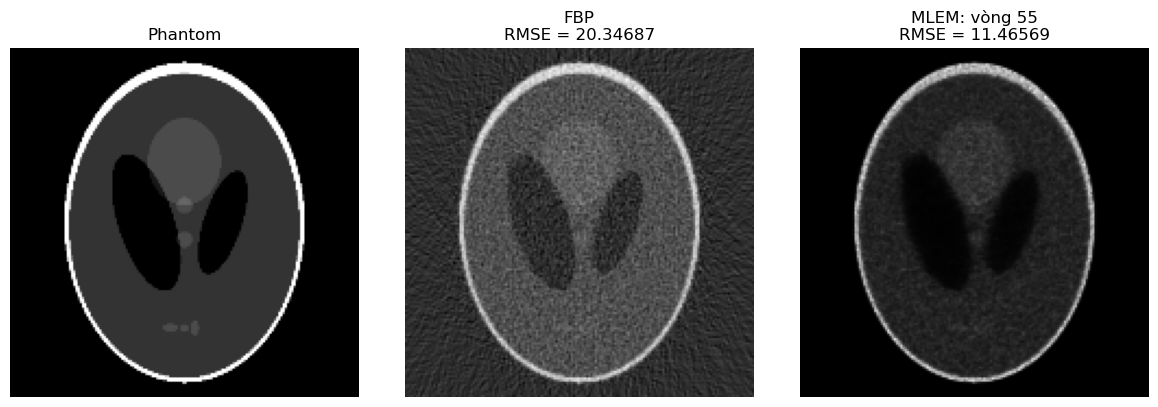

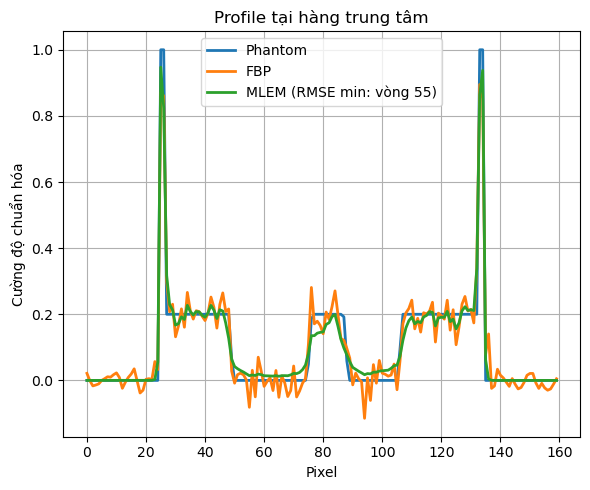

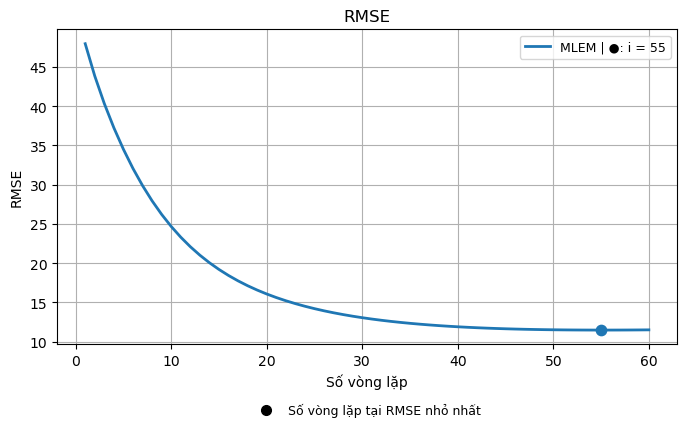

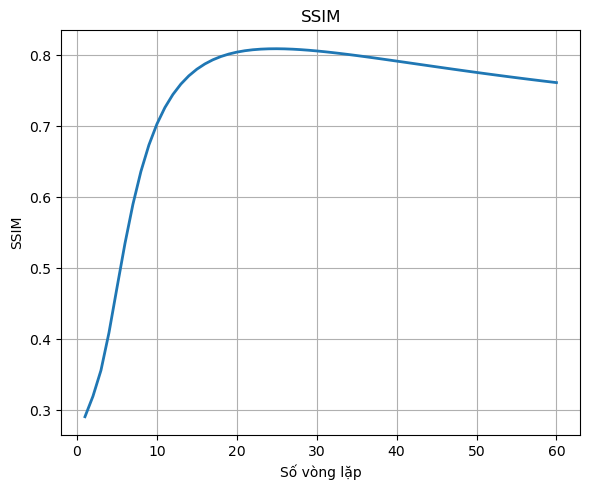

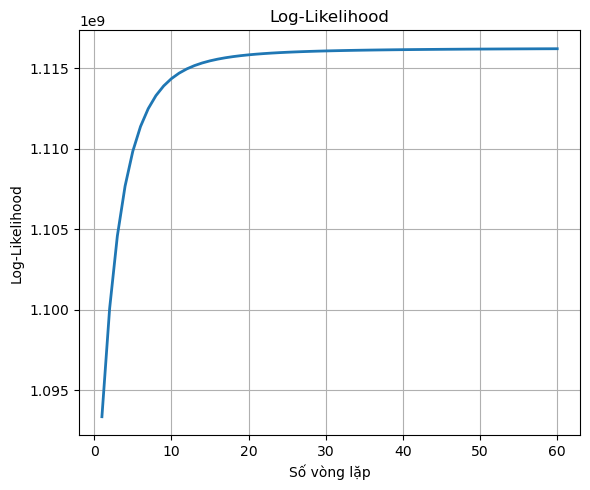

Đã cập nhật khảo sát: 5e+06
Số mức số đếm hiện có: 2


In [29]:
## Tái tạo hình ảnh FBP và MLEM, so sánh chất lượng hình ảnh
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from skimage import io, data_dir
from skimage.transform import radon, iradon
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# ==================== Thông số =====================
np.random.seed(0)
niter = 60
counts = int(5e6)
eps = 1e-6

# ===================== Phantom =====================
phantom_path = data_dir + "/phantom160.png"
image = io.imread(phantom_path, as_gray=True).astype(np.float32)
theta = np.arange(0, 180, 1)

# ===================== Phép chiếu =====================
sinogram = radon(image, theta, circle=False)
total = sinogram.sum()
measured = np.random.poisson(sinogram / total * counts).astype(np.float32)
measured *= total / counts

sensitivity = np.maximum(
    iradon(np.ones_like(measured), theta, filter_name=None, circle=False),
    eps
)

# ===================== Tái tạo MLEM =====================
x = np.ones_like(image)
rmse, psnr, ssim, loglike = [], [], [], []
best_rmse, best_iter, best_img = np.inf, 0, None

for k in range(niter):
    proj = radon(x, theta, circle=False)
    ratio = measured / (proj + eps)
    back = iradon(ratio, theta, filter_name=None, circle=False)
    x = np.maximum(x * back / sensitivity, eps)

    # Log-Likelihood
    proj2 = radon(x, theta, circle=False)
    mask = proj2 > 0
    loglike.append(
        (measured[mask] * np.log(proj2[mask]) - proj2[mask]).sum()
    )

    # RMSE không chuẩn hóa
    e = np.sqrt(np.mean((image - x) ** 2))
    rmse.append(e)

    # PSNR
    psnr.append(
        peak_signal_noise_ratio(
            image, x,
            data_range=image.max() - image.min()
        )
    )

    # SSIM
    ssim.append(
        structural_similarity(
            image, x,
            data_range=image.max() - image.min()
        )
    )

    if e < best_rmse:
        best_rmse, best_iter, best_img = e, k + 1, x.copy()

# ===================== Tái tạo FBP =====================
fbp = iradon(measured, theta, filter_name="ramp", circle=False)

rmse_fbp = np.sqrt(np.mean((image - fbp) ** 2))
psnr_fbp = peak_signal_noise_ratio(
    image, fbp,
    data_range=image.max() - image.min()
)
ssim_fbp = structural_similarity(
    image, fbp,
    data_range=image.max() - image.min()
)

print(f"FBP  | RMSE = {rmse_fbp:.5f} | PSNR = {psnr_fbp:.5f} | SSIM = {ssim_fbp:.5f}")
print(f"MLEM | RMSE nhỏ nhất: vòng {best_iter} | RMSE = {best_rmse:.5f}")
print(f"MLEM | PSNR = {psnr[best_iter-1]:.5f} | SSIM = {ssim[best_iter-1]:.5f}")

# ===================== Ảnh tái tạo =====================
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Phantom")

ax[1].imshow(fbp, cmap="gray")
ax[1].set_title(f"FBP\nRMSE = {rmse_fbp:.5f}")

ax[2].imshow(best_img, cmap="gray")
ax[2].set_title(f"MLEM: vòng {best_iter}\nRMSE = {best_rmse:.5f}")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

# ===================== Profile =====================
center = image.shape[0] // 2
half_width = 2

phantom_min = image.min()
phantom_range = image.max() - phantom_min + 1e-12

profile_true = image[center-half_width:center+half_width+1, :].mean(axis=0)
profile_fbp = fbp[center-half_width:center+half_width+1, :].mean(axis=0)
profile_mlem = best_img[center-half_width:center+half_width+1, :].mean(axis=0)

profile_true = (profile_true - phantom_min) / phantom_range
profile_fbp = (profile_fbp - phantom_min) / phantom_range
profile_mlem = (profile_mlem - phantom_min) / phantom_range

plt.figure(figsize=(6, 5))
plt.plot(profile_true, lw=2, label="Phantom")
plt.plot(profile_fbp, lw=2, label="FBP")
plt.plot(profile_mlem, lw=2, label=f"MLEM (RMSE min: vòng {best_iter})")
plt.title("Profile tại hàng trung tâm")
plt.xlabel("Pixel")
plt.ylabel("Cường độ chuẩn hóa")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===================== RMSE =====================
iteration = np.arange(1, niter + 1)
fig, ax = plt.subplots(figsize=(8, 5))

line_mlem, = ax.plot(iteration, rmse, lw=2)
color_mlem = line_mlem.get_color()

# ● RMSE nhỏ nhất
ax.scatter(best_iter, best_rmse, s=55, color=color_mlem, zorder=5)

# Ghi chú 1 - bên trong đồ thị
label_mlem = f"MLEM | ●: i = {best_iter}"
legend1 = ax.legend([line_mlem], [label_mlem], loc="upper right", fontsize=9)
ax.add_artist(legend1)

ax.set_title("RMSE")
ax.set_xlabel("Số vòng lặp")
ax.set_ylabel("RMSE")
ax.grid(True)

# Ghi chú 2 - bên dưới đồ thị
handle_min = Line2D(
    [0], [0],
    marker="o",
    linestyle="None",
    markerfacecolor="black",
    markeredgecolor="black",
    markersize=7
)

ax.legend(
    [handle_min],
    ["Số vòng lặp tại RMSE nhỏ nhất"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    frameon=False,
    fontsize=9
)

plt.subplots_adjust(bottom=0.25)
plt.show()

# ===================== SSIM =====================
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(iteration, ssim, lw=2)

ax.set_title("SSIM")
ax.set_xlabel("Số vòng lặp")
ax.set_ylabel("SSIM")
ax.grid(True)

plt.tight_layout()
plt.show()
# ===================== Log-Likelihood =====================
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(iteration, loglike, lw=2)

ax.set_title("Log-Likelihood")
ax.set_xlabel("Số vòng lặp")
ax.set_ylabel("Log-Likelihood")
ax.grid(True)

plt.tight_layout()
plt.show()
# ===================== Lưu kết quả khảo sát =====================
if "survey_results" not in globals():
    survey_results = []

result = {
    "count": counts,
    "label": {int(5e5): "5e5", int(1e6): "1e6", int(5e6): "5e6", int(1e7): "1e7"}[counts],
    "mlem_rmse": rmse,
    "mlem_psnr": psnr,
    "mlem_ssim": ssim,
    "mlem_loglike": loglike,
    "mlem_best_iter": best_iter
}

# Nếu chạy lại cùng mức số đếm thì thay kết quả cũ
survey_results = [r for r in survey_results if r["count"] != counts]
survey_results.append(result)

print(f"Đã cập nhật khảo sát: {counts:.0e}")
print(f"Số mức số đếm hiện có: {len(survey_results)}")

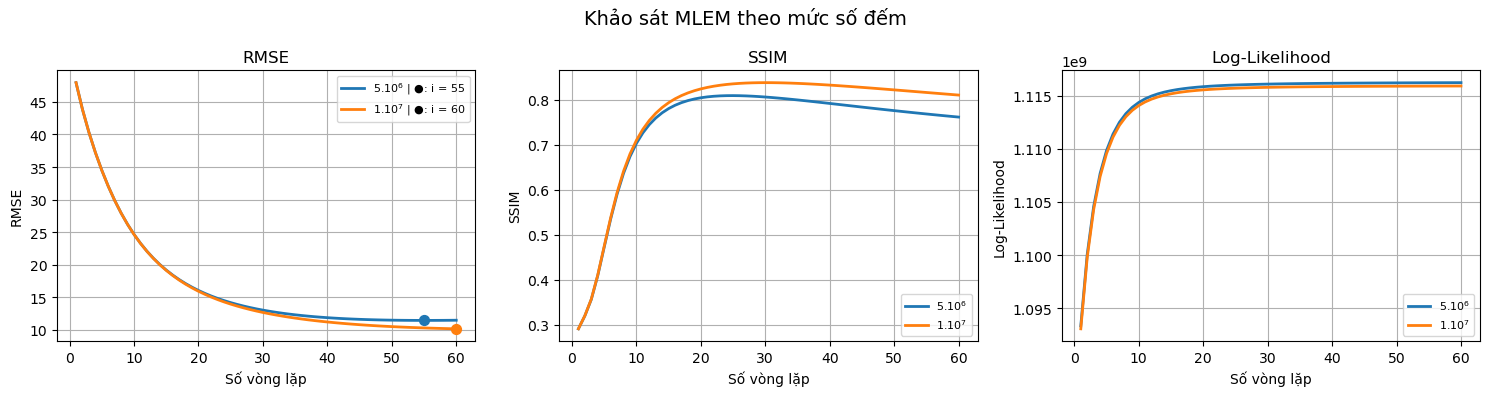

In [32]:
# ===================== Đồ thị tích lũy RMSE, SSIM và Log-Likelihood của MLEM =====================
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# ===================== Nhãn mức số đếm =====================
label_map = {
    int(5e5): r"$5.10^5$",
    int(1e6): r"$1.10^6$",
    int(5e6): r"$5.10^6$",
    int(1e7): r"$1.10^7$"}

# ===================== Dữ liệu khảo sát =====================
results = sorted(survey_results, key=lambda r: r["count"])
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
colors = []

# ===================== Vẽ RMSE =====================
for r in results:
    line, = ax[0].plot(np.arange(1, len(r["mlem_rmse"]) + 1),r["mlem_rmse"], lw=2)
    color = line.get_color()
    colors.append(color)
    ax[0].scatter(r["mlem_best_iter"],r["mlem_rmse"][r["mlem_best_iter"] - 1],s=50, color=color, zorder=5)

handles = [Line2D([0], [0], color=c, lw=2) for c in colors]
ax[0].legend(handles,[f'{label_map[r["count"]]} | ●: i = {r["mlem_best_iter"]}' for r in results],loc="upper right", fontsize=8)

# ===================== Vẽ SSIM =====================
for r, color in zip(results, colors):
    ax[1].plot(np.arange(1, len(r["mlem_ssim"]) + 1),r["mlem_ssim"], lw=2, color=color
               )
ax[1].legend(handles,[label_map[r["count"]] for r in results],loc="lower right", fontsize=8)

# ===================== Vẽ Log-Likelihood =====================
for r, color in zip(results, colors):
    ax[2].plot(
        np.arange(1, len(r["mlem_loglike"]) + 1),
        r["mlem_loglike"], lw=2, color=color
    )
ax[2].legend(handles,[label_map[r["count"]] for r in results],loc="lower right", fontsize=8)

# ===================== Thiết lập đồ thị =====================
titles = ["RMSE", "SSIM", "Log-Likelihood"]
ylabels = ["RMSE", "SSIM", "Log-Likelihood"]

for a, title, ylabel in zip(ax, titles, ylabels):
    a.set_title(title)
    a.set_xlabel("Số vòng lặp")
    a.set_ylabel(ylabel)
    a.grid(True)

fig.suptitle("Khảo sát MLEM theo mức số đếm", fontsize=14)
plt.tight_layout()
plt.show()